# W&B Demo Notebook

This notebook demonstrates:
1. Data exploration and class distribution logging
2. Hyperparameter sweeps
3. Optimizer comparison
4. Gradient norm analysis
5. Confusion matrix and error analysis


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import wandb
import matplotlib.pyplot as plt

from ann import NeuralNetwork
from utils.data_loader import load_data, CLASS_NAMES

c:\Users\ganes\.conda\envs\DA_Lab\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. Data Exploration

In [2]:
DATASET = 'mnist'  # change to 'fashion' for Fashion-MNIST
(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data(DATASET)

class_names = CLASS_NAMES[DATASET]
num_classes = len(class_names)

# Log 5 samples per class as a W&B Table
run = wandb.init(project='DA6401-Assignment1', name='data-exploration')

columns = ['class_id', 'class_name', 'image']
table   = wandb.Table(columns=columns)

for cls in range(num_classes):
    idx = np.where(y_train == cls)[0][:5]
    for i in idx:
        img = (X_train[i].reshape(28, 28) * 255).astype(np.uint8)
        table.add_data(cls, class_names[cls], wandb.Image(img))

run.log({'class_samples': table})
run.finish()
print('Data exploration logged to W&B.')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ganes\_netrc.


[DataLoader] mnist  train=54000  val=6000  test=10000


wandb: Currently logged in as: ganeshmula02 (ganeshmula02-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Data exploration logged to W&B.


## 2. Hyperparameter Sweep

In [3]:
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_acc', 'goal': 'maximize'},
    'parameters': {
        'epochs':        {'values': [5, 10]},
        'batch_size':    {'values': [32, 64, 128]},
        'learning_rate': {'distribution': 'log_uniform_values', 'min': 1e-4, 'max': 1e-1},
        'optimizer':     {'values': ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']},
        'num_layers':    {'values': [2, 3, 4]},
        'hidden_size':   {'values': [64, 128]},
        'activation':    {'values': ['relu', 'sigmoid', 'tanh']},
        'weight_init':   {'values': ['xavier', 'random']},
        'weight_decay':  {'values': [0.0, 1e-4, 1e-3]},
        'loss':          {'values': ['cross_entropy', 'mean_squared_error']},
    }
}


def sweep_train():
    run = wandb.init()
    cfg = run.config

    # Build args namespace from sweep config
    import argparse
    args = argparse.Namespace(
        dataset       = DATASET,
        epochs        = cfg.epochs,
        batch_size    = cfg.batch_size,
        learning_rate = cfg.learning_rate,
        optimizer     = cfg.optimizer,
        num_layers    = cfg.num_layers,
        hidden_size   = cfg.hidden_size,
        activation    = cfg.activation,
        weight_init   = cfg.weight_init,
        weight_decay  = cfg.weight_decay,
        loss          = cfg.loss,
    )

    model = NeuralNetwork(args)
    model.train(
        X_train, y_train,
        X_val=X_val, y_val=y_val,
        epochs=args.epochs,
        batch_size=args.batch_size,
        wandb_run=run,
    )
    run.finish()


sweep_id = wandb.sweep(sweep_config, project='DA6401-Assignment1')
wandb.agent(sweep_id, function=sweep_train, count=100)

Create sweep with ID: 25r37u6a
Sweep URL: https://wandb.ai/ganeshmula02-indian-institute-of-technology-madras/DA6401-Assignment1/sweeps/25r37u6a


wandb: Agent Starting Run: n16kf04i with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.0050312608015955435
wandb: 	loss: mean_squared_error
wandb: 	num_layers: 2
wandb: 	optimizer: adam
wandb: 	weight_decay: 0.001
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ganes\_netrc.


Epoch 1/5  train_loss=0.9033  train_acc=0.1036  val_loss=0.9024  val_acc=0.1113
Epoch 2/5  train_loss=0.9009  train_acc=0.0995  val_loss=0.9007  val_acc=0.0960
Epoch 3/5  train_loss=0.9002  train_acc=0.1036  val_loss=0.8999  val_acc=0.1113
Epoch 4/5  train_loss=0.9000  train_acc=0.1132  val_loss=0.9001  val_acc=0.1050


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 5/5  train_loss=0.8999  train_acc=0.1132  val_loss=0.8999  val_acc=0.1050


...

wandb: Agent Starting Run: 05zga5jv with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.000659753756930403
wandb: 	loss: mean_squared_error
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ganes\_netrc.


Epoch 1/10  train_loss=0.3778  train_acc=0.8998  val_loss=0.1318  val_acc=0.9158
Epoch 2/10  train_loss=0.1328  train_acc=0.9259  val_loss=0.0957  val_acc=0.9358
Epoch 3/10  train_loss=0.1031  train_acc=0.9416  val_loss=0.0731  val_acc=0.9522
Epoch 4/10  train_loss=0.0849  train_acc=0.9503  val_loss=0.0637  val_acc=0.9597
Epoch 5/10  train_loss=0.0722  train_acc=0.9587  val_loss=0.0571  val_acc=0.9630
Epoch 6/10  train_loss=0.0625  train_acc=0.9622  val_loss=0.0537  val_acc=0.9660
Epoch 7/10  train_loss=0.0555  train_acc=0.9697  val_loss=0.0474  val_acc=0.9677
Epoch 8/10  train_loss=0.0493  train_acc=0.9735  val_loss=0.0427  val_acc=0.9713
Epoch 9/10  train_loss=0.0447  train_acc=0.9730  val_loss=0.0449  val_acc=0.9693


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 10/10  train_loss=0.0403  train_acc=0.9763  val_loss=0.0419  val_acc=0.9722


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▃▅▆▆▇▇███
train_loss,█▃▂▂▂▁▁▁▁▁
val_acc,▁▃▆▆▇▇▇███
val_loss,█▅▃▃▂▂▁▁▁▁
epoch,10
train_acc,0.97626
train_loss,0.04027
val_acc,0.97217
val_loss,0.04193


## 3. Optimizer Comparison

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/10  train_loss=2.3241  train_acc=0.1292  val_loss=2.3188  val_acc=0.1377
Epoch 2/10  train_loss=2.3198  train_acc=0.1317  val_loss=2.3144  val_acc=0.1402
Epoch 3/10  train_loss=2.3156  train_acc=0.1342  val_loss=2.3102  val_acc=0.1430
Epoch 4/10  train_loss=2.3115  train_acc=0.1367  val_loss=2.3060  val_acc=0.1462
Epoch 5/10  train_loss=2.3074  train_acc=0.1402  val_loss=2.3018  val_acc=0.1495
Epoch 6/10  train_loss=2.3034  train_acc=0.1434  val_loss=2.2977  val_acc=0.1553
Epoch 7/10  train_loss=2.2995  train_acc=0.1469  val_loss=2.2936  val_acc=0.1583
Epoch 8/10  train_loss=2.2955  train_acc=0.1503  val_loss=2.2896  val_acc=0.1633
Epoch 9/10  train_loss=2.2917  train_acc=0.1540  val_loss=2.2856  val_acc=0.1685


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 10/10  train_loss=2.2878  train_acc=0.1582  val_loss=2.2816  val_acc=0.1745


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▂▂▃▄▄▅▆▇█
train_loss,█▇▆▆▅▄▃▂▂▁
val_acc,▁▁▂▃▃▄▅▆▇█
val_loss,█▇▆▆▅▄▃▃▂▁
epoch,10
train_acc,0.15819
train_loss,2.28778
val_acc,0.1745
val_loss,2.28159


...

epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▄▆▆▇▇▇█▇▇
train_loss,█▃▃▂▂▁▁▁▁▁
val_acc,▁▄▆▆█▇▇█▆▆
val_loss,█▄▂▄▁▁▂▂▄▇
epoch,10
train_acc,0.99096
train_loss,0.02123
val_acc,0.97483
val_loss,0.11287


Epoch 1/10  train_loss=0.2552  train_acc=0.9666  val_loss=0.1103  val_acc=0.9665
Epoch 2/10  train_loss=0.1058  train_acc=0.9766  val_loss=0.0962  val_acc=0.9695
Epoch 3/10  train_loss=0.0763  train_acc=0.9842  val_loss=0.0784  val_acc=0.9757
Epoch 4/10  train_loss=0.0564  train_acc=0.9849  val_loss=0.0884  val_acc=0.9773
Epoch 5/10  train_loss=0.0446  train_acc=0.9904  val_loss=0.0796  val_acc=0.9773
Epoch 6/10  train_loss=0.0368  train_acc=0.9881  val_loss=0.0908  val_acc=0.9733
Epoch 7/10  train_loss=0.0302  train_acc=0.9928  val_loss=0.0879  val_acc=0.9773
Epoch 8/10  train_loss=0.0282  train_acc=0.9951  val_loss=0.0857  val_acc=0.9780
Epoch 9/10  train_loss=0.0245  train_acc=0.9902  val_loss=0.0957  val_acc=0.9753


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 10/10  train_loss=0.0226  train_acc=0.9937  val_loss=0.1031  val_acc=0.9775


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▃▅▅▇▆▇█▇█
train_loss,█▄▃▂▂▁▁▁▁▁
val_acc,▁▃▇██▅██▆█
val_loss,█▅▁▃▁▄▃▃▅▆
epoch,10
train_acc,0.99372
train_loss,0.02259
val_acc,0.9775
val_loss,0.10309


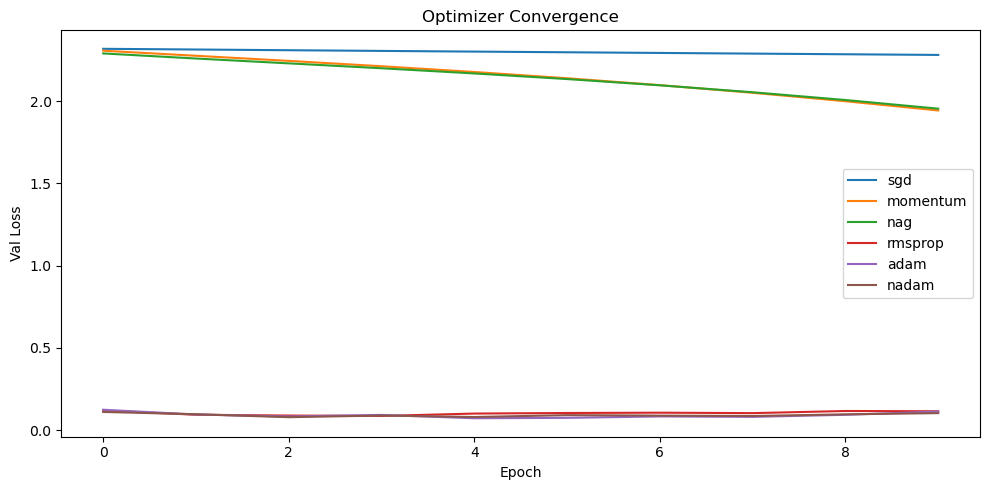

In [4]:
import argparse

optimizers = ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']
results = {}

for opt in optimizers:
    args = argparse.Namespace(
        dataset='mnist', epochs=10, batch_size=64,
        learning_rate=0.001, optimizer=opt,
        num_layers=3, hidden_size=128, activation='relu',
        weight_init='xavier', weight_decay=0.0, loss='cross_entropy',
    )
    run = wandb.init(project='DA6401-Assignment1', name=f'optimizer-{opt}', reinit=True)
    model = NeuralNetwork(args)
    history = model.train(X_train, y_train, X_val=X_val, y_val=y_val,
                          epochs=10, batch_size=64, wandb_run=run)
    results[opt] = history
    run.finish()

# Plot convergence curves
fig, ax = plt.subplots(figsize=(10, 5))
for opt, hist in results.items():
    ax.plot(hist['val_loss'], label=opt)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
ax.set_title('Optimizer Convergence'); ax.legend()
plt.tight_layout(); plt.savefig('../models/optimizer_comparison.png', dpi=150)
plt.show()

## 4. Gradient Norm Analysis (Vanishing Gradient)

In [ ]:
import argparse

def run_gradient_analysis(activation, run_name):
    args = argparse.Namespace(
        dataset='mnist', epochs=10, batch_size=64,
        learning_rate=0.001, optimizer='adam',
        num_layers=5, hidden_size=128, activation=activation,
        weight_init='xavier', weight_decay=0.0, loss='cross_entropy',
    )
    model = NeuralNetwork(args)
    run   = wandb.init(project='DA6401-Assignment1', name=run_name, reinit=True)

    for epoch in range(args.epochs):
        perm = np.random.permutation(len(X_train))[:args.batch_size]
        Xb, yb = X_train[perm], y_train[perm]
        logits = model.forward(Xb)
        model.backward(yb, logits)
        model.update_weights()

        # Log gradient norm for first hidden layer
        grad_norm = float(np.linalg.norm(model.layers[0].grad_W))
        run.log({'epoch': epoch + 1, 'first_layer_grad_norm': grad_norm})

    run.finish()

run_gradient_analysis('sigmoid', 'grad-analysis-sigmoid')
run_gradient_analysis('relu',    'grad-analysis-relu')

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
first_layer_grad_norm,▇█▄▃▂▃▂▁▁▃
epoch,10
first_layer_grad_norm,2e-05


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
first_layer_grad_norm,▁▁▂▂▄▅▆█▆█
epoch,10
first_layer_grad_norm,0.00674


## 5. Confusion Matrix — Best Model

Model loaded ← ../src/models/best_model.npy


c:\Users\ganes\.conda\envs\DA_Lab\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


[DataLoader] mnist  train=54000  val=6000  test=10000


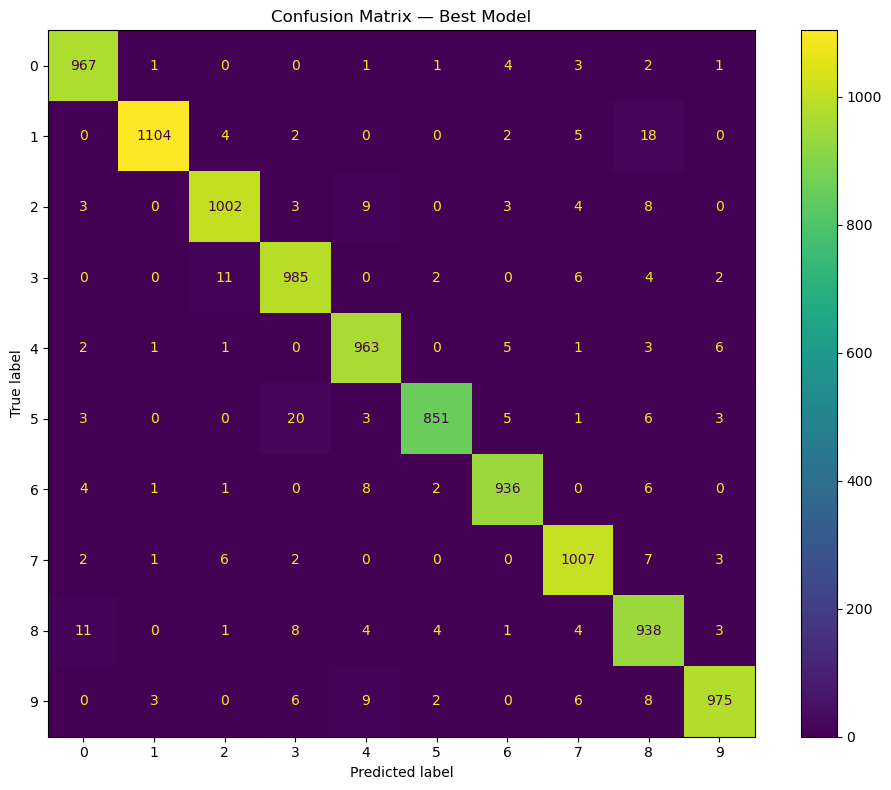

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ganes\_netrc.
wandb: Currently logged in as: ganeshmula02 (ganeshmula02-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [1]:
import json
import argparse
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

from ann import NeuralNetwork
from utils.data_loader import load_data, CLASS_NAMES

# ── Fix: point to where train.py actually saved the files ──
config_path = '../src/models/best_config.json'
model_path  = '../src/models/best_model.npy'

# Load config
with open(config_path) as f:
    cfg = json.load(f)

# Rebuild model from config
args = argparse.Namespace(**{k: v for k, v in cfg.items()
                              if k in ('dataset','epochs','batch_size','learning_rate',
                                       'optimizer','num_layers','hidden_size','activation',
                                       'weight_init','weight_decay','loss')})
model = NeuralNetwork(args)
model.load(model_path)

# Load test data
_, _, (X_test_d, y_test_d) = load_data(args.dataset)
logits = model.forward(X_test_d)
y_pred = np.argmax(logits, axis=1)

# Plot confusion matrix
cm   = confusion_matrix(y_test_d, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES[args.dataset])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True)
plt.title('Confusion Matrix — Best Model')
plt.tight_layout()
plt.savefig('../src/models/confusion_matrix.png', dpi=150)
plt.show()

# Log to W&B
import wandb
run = wandb.init(project='DA6401-Assignment1', name='confusion-matrix')
run.log({'confusion_matrix': wandb.Image('../src/models/confusion_matrix.png')})
run.finish()

## 2.5 — Dead Neuron Investigation

In [1]:
import sys, os, argparse
import numpy as np
import wandb
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from ann import NeuralNetwork
from utils.data_loader import load_data

(X_train, y_train), (X_val, y_val), (X_test, y_test) = load_data('mnist')

def run_dead_neuron(activation, lr, run_name):
    args = argparse.Namespace(
        dataset='mnist', epochs=10, batch_size=64,
        learning_rate=lr, optimizer='adam',
        num_layers=3, hidden_size=128, activation=activation,
        weight_init='xavier', weight_decay=0.0, loss='cross_entropy',
    )
    run = wandb.init(project='DA6401-Assignment1', name=run_name, reinit=True)
    model = NeuralNetwork(args)

    for epoch in range(10):
        perm = np.random.permutation(len(X_train))
        for start in range(0, len(X_train), 64):
            idx = perm[start:start+64]
            Xb, yb = X_train[idx], y_train[idx]
            logits = model.forward(Xb)
            model.backward(yb, logits)
            model.update_weights()

        # Check activations of first hidden layer on full val set
        _ = model.forward(X_val)
        activations = model.layers[0]._a  # post-activation output

        dead_pct = float(np.mean(activations == 0) * 100)
        val_metrics = model.evaluate(X_val, y_val)

        run.log({
            'epoch': epoch + 1,
            'dead_neuron_pct': dead_pct,
            'val_acc': val_metrics['accuracy'],
            'activation_mean': float(np.mean(activations)),
            'activation_std':  float(np.std(activations)),
        })
        print(f"[{run_name}] Epoch {epoch+1} | dead={dead_pct:.1f}% | val_acc={val_metrics['accuracy']:.4f}")

    run.finish()

# ReLU with HIGH learning rate (dead neurons expected)
run_dead_neuron('relu', lr=0.1,   run_name='dead-neuron-relu-high-lr')
# Tanh for comparison (no dead neurons)
run_dead_neuron('tanh', lr=0.001, run_name='dead-neuron-tanh-low-lr')

c:\Users\ganes\.conda\envs\DA_Lab\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ganes\_netrc.


[DataLoader] mnist  train=54000  val=6000  test=10000


wandb: Currently logged in as: ganeshmula02 (ganeshmula02-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[dead-neuron-relu-high-lr] Epoch 1 | dead=99.3% | val_acc=0.3682
[dead-neuron-relu-high-lr] Epoch 2 | dead=99.2% | val_acc=0.2960
[dead-neuron-relu-high-lr] Epoch 3 | dead=99.1% | val_acc=0.0978
[dead-neuron-relu-high-lr] Epoch 4 | dead=99.1% | val_acc=0.0952
[dead-neuron-relu-high-lr] Epoch 5 | dead=99.1% | val_acc=0.1050
[dead-neuron-relu-high-lr] Epoch 6 | dead=99.1% | val_acc=0.0960
[dead-neuron-relu-high-lr] Epoch 7 | dead=99.1% | val_acc=0.0952
[dead-neuron-relu-high-lr] Epoch 8 | dead=99.1% | val_acc=0.0960
[dead-neuron-relu-high-lr] Epoch 9 | dead=99.1% | val_acc=0.0915


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

activation_mean,▁▅████████
activation_std,▁▅████████
dead_neuron_pct,█▅▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
val_acc,█▆▁▁▁▁▁▁▁▁
activation_mean,0.70446
activation_std,9.32883
dead_neuron_pct,99.10156
epoch,10
val_acc,0.096


[dead-neuron-tanh-low-lr] Epoch 1 | dead=0.0% | val_acc=0.9610
[dead-neuron-tanh-low-lr] Epoch 2 | dead=0.0% | val_acc=0.9690
[dead-neuron-tanh-low-lr] Epoch 3 | dead=0.0% | val_acc=0.9728
[dead-neuron-tanh-low-lr] Epoch 4 | dead=0.0% | val_acc=0.9703
[dead-neuron-tanh-low-lr] Epoch 5 | dead=0.0% | val_acc=0.9748
[dead-neuron-tanh-low-lr] Epoch 6 | dead=0.0% | val_acc=0.9755
[dead-neuron-tanh-low-lr] Epoch 7 | dead=0.0% | val_acc=0.9762
[dead-neuron-tanh-low-lr] Epoch 8 | dead=0.0% | val_acc=0.9785
[dead-neuron-tanh-low-lr] Epoch 9 | dead=0.0% | val_acc=0.9770


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[dead-neuron-tanh-low-lr] Epoch 10 | dead=0.0% | val_acc=0.9758


activation_mean,▆█▃▆█▅▅▁▃█
activation_std,▁▃▅▆▆▇▇▇██
dead_neuron_pct,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
val_acc,▁▄▆▅▇▇▇█▇▇
activation_mean,0.02094
activation_std,0.79853
dead_neuron_pct,0
epoch,10
val_acc,0.97583


## 2.6 — Loss Function Comparison

In [2]:
def run_loss_comparison(loss_name, run_name):
    args = argparse.Namespace(
        dataset='mnist', epochs=15, batch_size=64,
        learning_rate=0.001, optimizer='adam',
        num_layers=3, hidden_size=128, activation='relu',
        weight_init='xavier', weight_decay=0.0, loss=loss_name,
    )
    run = wandb.init(project='DA6401-Assignment1', name=run_name, reinit=True)
    model = NeuralNetwork(args)
    model.train(
        X_train, y_train,
        X_val=X_val, y_val=y_val,
        epochs=15, batch_size=64,
        wandb_run=run,
    )
    run.finish()

run_loss_comparison('cross_entropy',      'loss-cross-entropy')
run_loss_comparison('mean_squared_error', 'loss-mse')

Epoch 1/15  train_loss=0.2756  train_acc=0.9643  val_loss=0.1133  val_acc=0.9675
Epoch 2/15  train_loss=0.1058  train_acc=0.9738  val_loss=0.1049  val_acc=0.9675
Epoch 3/15  train_loss=0.0752  train_acc=0.9802  val_loss=0.0929  val_acc=0.9730
Epoch 4/15  train_loss=0.0565  train_acc=0.9845  val_loss=0.0871  val_acc=0.9743
Epoch 5/15  train_loss=0.0448  train_acc=0.9903  val_loss=0.0761  val_acc=0.9788
Epoch 6/15  train_loss=0.0377  train_acc=0.9893  val_loss=0.0838  val_acc=0.9787
Epoch 7/15  train_loss=0.0304  train_acc=0.9943  val_loss=0.0833  val_acc=0.9795
Epoch 8/15  train_loss=0.0271  train_acc=0.9930  val_loss=0.0932  val_acc=0.9765
Epoch 9/15  train_loss=0.0280  train_acc=0.9935  val_loss=0.0800  val_acc=0.9808
Epoch 10/15  train_loss=0.0203  train_acc=0.9934  val_loss=0.0888  val_acc=0.9782
Epoch 11/15  train_loss=0.0195  train_acc=0.9956  val_loss=0.0887  val_acc=0.9795
Epoch 12/15  train_loss=0.0191  train_acc=0.9951  val_loss=0.1041  val_acc=0.9778
Epoch 13/15  train_loss=0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 15/15  train_loss=0.0164  train_acc=0.9964  val_loss=0.0956  val_acc=0.9787


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▄▅▇▆▇▇▇▇███▇█
train_loss,█▃▃▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▁▄▅▇▇▇▆█▇▇▆█▇▇
val_loss,█▆▄▃▁▂▂▄▂▃▃▆▄█▅
epoch,15
train_acc,0.99639
train_loss,0.01642
val_acc,0.97867
val_loss,0.09558


Epoch 1/15  train_loss=0.1270  train_acc=0.9557  val_loss=0.0620  val_acc=0.9597
Epoch 2/15  train_loss=0.0575  train_acc=0.9641  val_loss=0.0535  val_acc=0.9660
Epoch 3/15  train_loss=0.0436  train_acc=0.9802  val_loss=0.0346  val_acc=0.9770
Epoch 4/15  train_loss=0.0356  train_acc=0.9804  val_loss=0.0400  val_acc=0.9737
Epoch 5/15  train_loss=0.0301  train_acc=0.9866  val_loss=0.0318  val_acc=0.9790
Epoch 6/15  train_loss=0.0261  train_acc=0.9855  val_loss=0.0359  val_acc=0.9768
Epoch 7/15  train_loss=0.0240  train_acc=0.9859  val_loss=0.0377  val_acc=0.9777
Epoch 8/15  train_loss=0.0211  train_acc=0.9904  val_loss=0.0332  val_acc=0.9797
Epoch 9/15  train_loss=0.0196  train_acc=0.9889  val_loss=0.0355  val_acc=0.9782
Epoch 10/15  train_loss=0.0190  train_acc=0.9869  val_loss=0.0401  val_acc=0.9755
Epoch 11/15  train_loss=0.0176  train_acc=0.9892  val_loss=0.0378  val_acc=0.9773
Epoch 12/15  train_loss=0.0171  train_acc=0.9925  val_loss=0.0364  val_acc=0.9775
Epoch 13/15  train_loss=0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 15/15  train_loss=0.0142  train_acc=0.9919  val_loss=0.0335  val_acc=0.9803


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▆▆▇▇▇█▇▇▇█▇▇█
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▇▆█▇▇█▇▆▇▇▆▇█
val_loss,█▆▂▃▁▂▂▁▂▃▂▂▃▃▁
epoch,15
train_acc,0.99194
train_loss,0.01416
val_acc,0.98033
val_loss,0.03354


## 2.7 — Global Performance Overlay

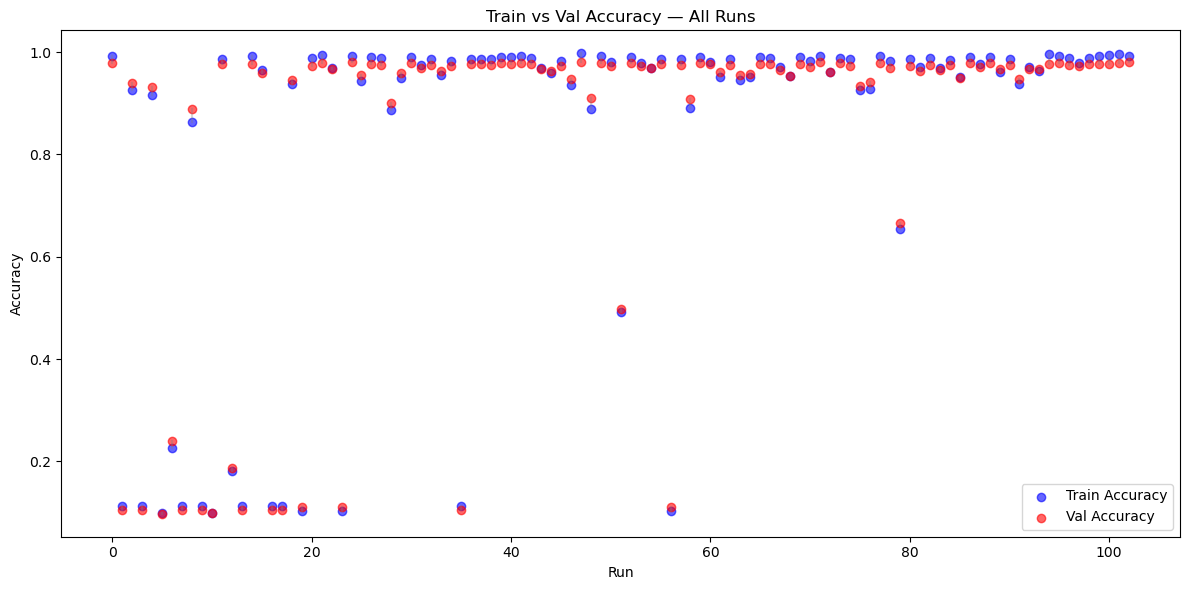

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [4]:
import wandb
api = wandb.Api()

runs = api.runs("ganeshmula02-indian-institute-of-technology-madras/DA6401-Assignment1")

train_accs, val_accs, run_names = [], [], []

for r in runs:
    history = r.history(keys=["train_acc", "val_acc"], pandas=False)
    if history:
        last = history[-1]
        if "train_acc" in last and "val_acc" in last:
            train_accs.append(last["train_acc"])
            val_accs.append(last["val_acc"])
            run_names.append(r.name)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(run_names))
ax.scatter(x, train_accs, label='Train Accuracy', color='blue', alpha=0.6)
ax.scatter(x, val_accs,   label='Val Accuracy',   color='red',  alpha=0.6)
for i in range(len(run_names)):
    ax.plot([i, i], [val_accs[i], train_accs[i]], 'gray', alpha=0.3)
ax.set_xlabel('Run')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Val Accuracy — All Runs')
ax.legend()
plt.tight_layout()
plt.savefig('../models/global_performance.png', dpi=150)
plt.show()

# Log to W&B
run = wandb.init(project='DA6401-Assignment1', name='global-performance', reinit=True)
run.log({'global_performance': wandb.Image('../models/global_performance.png')})
run.finish()

## 2.8 — Confusion Matrix + Creative Failure Visualization

Model loaded ← ../src/best_model.npy
[DataLoader] mnist  train=54000  val=6000  test=10000


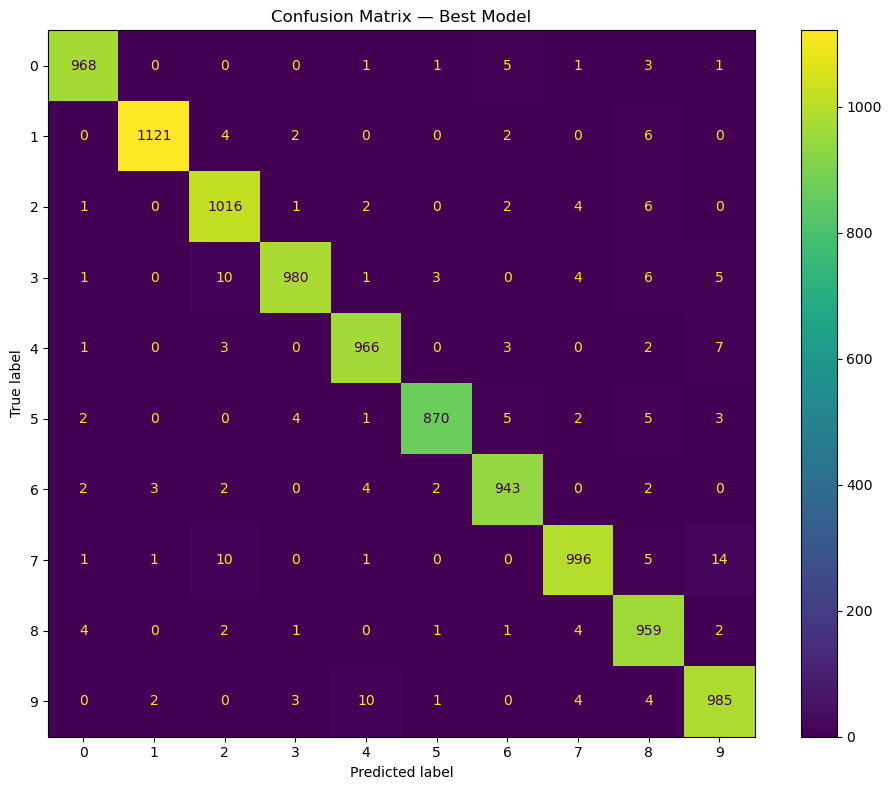

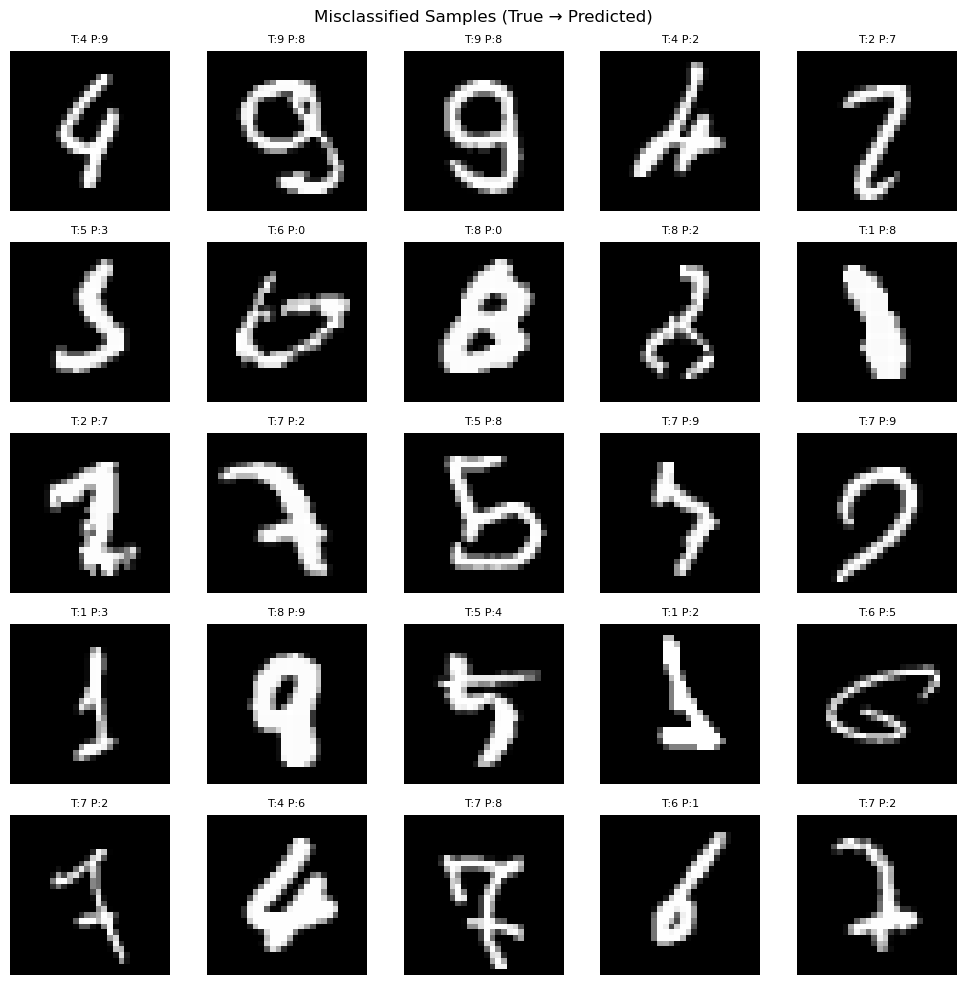

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [5]:
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from utils.data_loader import CLASS_NAMES

config_path = '../src/best_config.json'
model_path  = '../src/best_model.npy'

with open(config_path) as f:
    cfg = json.load(f)

args = argparse.Namespace(**{k: v for k, v in cfg.items()
                              if k in ('dataset','epochs','batch_size','learning_rate',
                                       'optimizer','num_layers','hidden_size','activation',
                                       'weight_init','weight_decay','loss')})
model = NeuralNetwork(args)
model.load(model_path)

_, _, (X_test_d, y_test_d) = load_data(args.dataset)
logits = model.forward(X_test_d)
y_pred = np.argmax(logits, axis=1)

# Standard confusion matrix
cm = confusion_matrix(y_test_d, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES[args.dataset])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True)
plt.title('Confusion Matrix — Best Model')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()

# Creative: show a grid of misclassified images
wrong_idx = np.where(y_pred != y_test_d)[0][:25]
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, idx in enumerate(wrong_idx):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test_d[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'T:{y_test_d[idx]} P:{y_pred[idx]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Misclassified Samples (True → Predicted)', fontsize=12)
plt.tight_layout()
plt.savefig('../models/misclassified.png', dpi=150)
plt.show()

run = wandb.init(project='DA6401-Assignment1', name='error-analysis', reinit=True)
run.log({
    'confusion_matrix':   wandb.Image('../models/confusion_matrix.png'),
    'misclassified_grid': wandb.Image('../models/misclassified.png'),
})
run.finish()

## 2.9 — Weight Init Symmetry

In [6]:
def run_weight_init_symmetry(weight_init, run_name):
    args = argparse.Namespace(
        dataset='mnist', epochs=1, batch_size=64,
        learning_rate=0.01, optimizer='sgd',
        num_layers=3, hidden_size=128, activation='relu',
        weight_init=weight_init, weight_decay=0.0, loss='cross_entropy',
    )
    run = wandb.init(project='DA6401-Assignment1', name=run_name, reinit=True)
    model = NeuralNetwork(args)

    # Track gradients of 5 specific neurons in first hidden layer
    neuron_ids = [0, 1, 2, 3, 4]

    iteration = 0
    for start in range(0, min(50 * 64, len(X_train)), 64):
        if iteration >= 50:
            break
        Xb = X_train[start:start+64]
        yb = y_train[start:start+64]
        logits = model.forward(Xb)
        model.backward(yb, logits)

        # Log gradient of each neuron (column of grad_W in first layer)
        log_dict = {'iteration': iteration + 1}
        for n in neuron_ids:
            grad_norm = float(np.linalg.norm(model.layers[0].grad_W[:, n]))
            log_dict[f'neuron_{n}_grad_norm'] = grad_norm

        run.log(log_dict)
        model.update_weights()
        iteration += 1

    run.finish()

run_weight_init_symmetry('zeros',  'weight-init-zeros')
run_weight_init_symmetry('xavier', 'weight-init-xavier')

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_1_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_2_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_3_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_4_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
iteration,50
neuron_0_grad_norm,0
neuron_1_grad_norm,0
neuron_2_grad_norm,0
neuron_3_grad_norm,0


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,▅▅▂▄▅▄▅▄▄▄▆▄▂▁▄▂▃▁▆▂▂▂▆▃▃▅█▄▄▅▃▃▃▁▃▃▇▅▃▃
neuron_1_grad_norm,▂▁▂▂▂▁▁▂▂▃▂▄▂▂▃▃▄▇▁▁▂▃▁▃▁▂▂▂▄█▃▂▆▅▂▂▄▂▂▂
neuron_2_grad_norm,▃▁▃▁▂▂▃▂▂▂▃▂▅▂▂▆▃▅▂▃▂▂█▃▃▃▄▄▄▂▃▂▂▃▃▃▄▃▃▃
neuron_3_grad_norm,▆▅▄▃▇▅▄▅▆▆▅█▃▄▃▇▁▄▆▄▅▄▃▃▅▃▄▅▅▅▅▆▄▅▂█▆▄▄▅
neuron_4_grad_norm,▁▃▆▄▄▄▂▃▂▁▇▄▃▃▄▇█▃█▄▄▄▅▇▄▅▂▄▃▄▅▃▂▃▃▄▄▄▂▃
iteration,50
neuron_0_grad_norm,0.00105
neuron_1_grad_norm,0.00051
neuron_2_grad_norm,0.00052
neuron_3_grad_norm,0.00057


## 2.10 — Fashion-MNIST Transfer

In [7]:
configs = [
    # Config 1 — Best MNIST config
    dict(num_layers=3, hidden_size=128, activation='relu',   optimizer='adam',  lr=0.001, name='fashion-adam-relu-3x128'),
    # Config 2 — Deeper with tanh
    dict(num_layers=4, hidden_size=128, activation='tanh',   optimizer='nadam', lr=0.001, name='fashion-nadam-tanh-4x128'),
    # Config 3 — Wider with momentum
    dict(num_layers=3, hidden_size=128, activation='relu',   optimizer='nadam', lr=0.0005, name='fashion-nadam-relu-3x128'),
]

for cfg in configs:
    args = argparse.Namespace(
        dataset='fashion', epochs=15, batch_size=64,
        learning_rate=cfg['lr'], optimizer=cfg['optimizer'],
        num_layers=cfg['num_layers'], hidden_size=cfg['hidden_size'],
        activation=cfg['activation'], weight_init='xavier',
        weight_decay=0.0, loss='cross_entropy',
    )
    (Xtr, ytr), (Xv, yv), (Xte, yte) = load_data('fashion')
    run = wandb.init(project='DA6401-Assignment1', name=cfg['name'], reinit=True)
    model = NeuralNetwork(args)
    model.train(Xtr, ytr, X_val=Xv, y_val=yv, epochs=15, batch_size=64, wandb_run=run)
    test_m = model.evaluate(Xte, yte)
    run.log({'test_accuracy': test_m['accuracy'], 'test_f1': test_m['f1']})
    print(f"{cfg['name']} → test_acc={test_m['accuracy']:.4f}")
    run.finish()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[DataLoader] fashion  train=54000  val=6000  test=10000


Epoch 1/15  train_loss=0.5170  train_acc=0.8605  val_loss=0.3965  val_acc=0.8553
Epoch 2/15  train_loss=0.3700  train_acc=0.8702  val_loss=0.3874  val_acc=0.8612
Epoch 3/15  train_loss=0.3328  train_acc=0.8857  val_loss=0.3412  val_acc=0.8697
Epoch 4/15  train_loss=0.3132  train_acc=0.8974  val_loss=0.3341  val_acc=0.8792
Epoch 5/15  train_loss=0.2924  train_acc=0.8961  val_loss=0.3380  val_acc=0.8767
Epoch 6/15  train_loss=0.2787  train_acc=0.9066  val_loss=0.3265  val_acc=0.8850
Epoch 7/15  train_loss=0.2663  train_acc=0.9059  val_loss=0.3316  val_acc=0.8838
Epoch 8/15  train_loss=0.2563  train_acc=0.9062  val_loss=0.3300  val_acc=0.8817
Epoch 9/15  train_loss=0.2418  train_acc=0.9202  val_loss=0.3127  val_acc=0.8890
Epoch 10/15  train_loss=0.2343  train_acc=0.9213  val_loss=0.3064  val_acc=0.8908
Epoch 11/15  train_loss=0.2237  train_acc=0.9233  val_loss=0.3194  val_acc=0.8888
Epoch 12/15  train_loss=0.2209  train_acc=0.9168  val_loss=0.3478  val_acc=0.8790
Epoch 13/15  train_loss=0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 15/15  train_loss=0.1993  train_acc=0.9255  val_loss=0.3540  val_acc=0.8865
fashion-adam-relu-3x128 → test_acc=0.8824


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_f1,▁
train_acc,▁▂▄▅▅▆▆▆▇██▇███
train_loss,█▅▄▄▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▂▄▆▅▇▇▆███▆█▇▇
val_loss,█▇▄▃▃▃▃▃▁▁▂▄▄▄▅
epoch,15
test_accuracy,0.8824
test_f1,0.88214
train_acc,0.92548


...

[DataLoader] fashion  train=54000  val=6000  test=10000


Epoch 1/15  train_loss=0.5229  train_acc=0.8544  val_loss=0.4267  val_acc=0.8477
Epoch 2/15  train_loss=0.3747  train_acc=0.8745  val_loss=0.3775  val_acc=0.8688
Epoch 3/15  train_loss=0.3359  train_acc=0.8853  val_loss=0.3492  val_acc=0.8737
Epoch 4/15  train_loss=0.3124  train_acc=0.8931  val_loss=0.3336  val_acc=0.8793
Epoch 5/15  train_loss=0.2945  train_acc=0.8976  val_loss=0.3320  val_acc=0.8775
Epoch 6/15  train_loss=0.2789  train_acc=0.9033  val_loss=0.3373  val_acc=0.8805
Epoch 7/15  train_loss=0.2642  train_acc=0.9056  val_loss=0.3304  val_acc=0.8802
Epoch 8/15  train_loss=0.2527  train_acc=0.9135  val_loss=0.3257  val_acc=0.8852
Epoch 9/15  train_loss=0.2426  train_acc=0.9130  val_loss=0.3357  val_acc=0.8828
Epoch 10/15  train_loss=0.2346  train_acc=0.9231  val_loss=0.3055  val_acc=0.8897
Epoch 11/15  train_loss=0.2234  train_acc=0.9257  val_loss=0.3200  val_acc=0.8910
Epoch 12/15  train_loss=0.2149  train_acc=0.9297  val_loss=0.3175  val_acc=0.8910
Epoch 13/15  train_loss=0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 15/15  train_loss=0.1940  train_acc=0.9315  val_loss=0.3360  val_acc=0.8880
fashion-nadam-relu-3x128 → test_acc=0.8833


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_f1,▁
train_acc,▁▃▄▄▅▅▆▆▆▇▇█▇██
train_loss,█▅▄▄▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▄▅▆▆▆▆▇▇███▇██
val_loss,█▅▄▃▃▃▂▂▃▁▂▂▃▂▃
epoch,15
test_accuracy,0.8833
test_f1,0.881
train_acc,0.93152
